In [1]:
import inspect

import cmasher as cmr
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit, minimize
from scipy.stats import gaussian_kde, lognorm, spearmanr
from sklearn.linear_model import RANSACRegressor
from sklearn.svm import SVC, LinearSVC

# plt.rc("font", family="Nimbus Roman")
plt.rc("font", family="Nimbus Roman No9 L")

SMALL_SIZE = 10
MEDIUM_SIZE = 10
BIGGER_SIZE = 10

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [ ]:
sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]
sim_cmap = plt.get_cmap("tab10")
sim_colors = [sim_cmap(i) for i in np.linspace(0, 1, len(sim_lst))]

min_mass = 10**5

sim_dir = "/Users/z5114326/Documents/simulations/"

snap = 600

public_snapshot_file = sim_dir + "snapshot_times_public.txt"
pub_data = pd.read_table(public_snapshot_file, comment="#", header=None, sep=r"\s+")
pub_data.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
time = float(pub_data[pub_data["index"] == snap]["time_Gyr"].values[0])

In [ ]:
sim_dict = {}
for sim in sim_lst:
    ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
    ghost_data = h5py.File(ghost_file, "r")

    sim_dict[sim] = {}
    for it_id in ghost_data.keys():
        src_dat = ghost_data[it_id]["source"]

        amsk = src_dat["grpid"][()] == 0
        grpid = src_dat["grpid"][()]

        m_tfo = 10 ** src_dat["logm_tfor"][()]
        m_tfo_ev = 0.55 * (10 ** src_dat["logm_tfor"][()])

        m_tz0_log = src_dat["logm_tz0"][()]
        m_tz0 = np.array([10**x if x != -1 else 0 for x in m_tz0_log])

        tfor = src_dat["tfor"][()]
        tdis = src_dat["tdis"][()]
        tacc = src_dat["tacc"][()]

        feh = src_dat["feh"][()]

        rz0 = np.linalg.norm(src_dat["pxyz_snap600"][()], axis=1)

        age = time - tfor
        age_p = np.array([x - y if x != -1 else time - y for x, y in zip(tdis, tfor)])

        t_tz0 = src_dat["torb_600"][()]
        s_tz0 = np.array(src_dat["s_flag"][()], dtype=bool)

        ml = m_tfo_ev - m_tz0
        ml_rate = (m_tfo_ev - m_tz0) / age_p

        m_tfo_msk = m_tfo >= min_mass

        sim_dict[sim][it_id] = {}
        sim_dict[sim][it_id]["m_tfo"] = m_tfo
        sim_dict[sim][it_id]["m_tfo_ev"] = m_tfo_ev
        sim_dict[sim][it_id]["m_tz0"] = m_tz0
        sim_dict[sim][it_id]["tfor"] = tfor
        sim_dict[sim][it_id]["tdis"] = tdis
        sim_dict[sim][it_id]["age"] = age
        sim_dict[sim][it_id]["age_p"] = age_p
        sim_dict[sim][it_id]["t_tz0"] = t_tz0
        sim_dict[sim][it_id]["s_tz0"] = s_tz0
        sim_dict[sim][it_id]["ml"] = ml
        sim_dict[sim][it_id]["ml_rate"] = ml_rate
        sim_dict[sim][it_id]["acc"] = amsk
        sim_dict[sim][it_id]["grp"] = grpid
        sim_dict[sim][it_id]["feh"] = feh
        sim_dict[sim][it_id]["rz0"] = rz0

In [4]:
def tdis_cut(x0, y0, x1, y1):
    X0 = np.stack((x0, y0), axis=1)
    X1 = np.stack((x1, y1), axis=1)

    X = np.vstack((X0, X1))
    Y = np.array([0] * len(X0) + [1] * len(X1))  # labels

    clf = SVC(kernel="linear")
    clf.fit(X, Y)

    w = clf.coef_[0]
    b = clf.intercept_[0]

    m = -(w[0] / w[1])
    c = -(b / w[1])

    return m, c

(1.9952623149688795, 12589.254117941662)

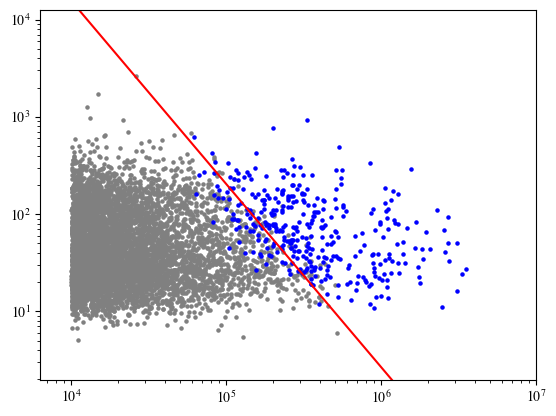

In [5]:
sim = "m12i"
it_id = "it001"
in_msk = True

tcut = 10

acc = sim_dict[sim][it_id]["acc"]
mfor = sim_dict[sim][it_id]["m_tfo"]
pz0 = sim_dict[sim][it_id]["t_tz0"]
sz0 = sim_dict[sim][it_id]["s_tz0"]
tdis = sim_dict[sim][it_id]["tdis"].copy()
tfor = sim_dict[sim][it_id]["tfor"]
tdis[tdis == -1] = np.inf

tfor_msk = tfor <= tcut
tdis_msk = tdis <= tcut

x0 = mfor[tfor_msk & tdis_msk & acc]
y0 = pz0[tfor_msk & tdis_msk & acc]
x1 = mfor[tfor_msk & ~tdis_msk & acc]
y1 = pz0[tfor_msk & ~tdis_msk & acc]

log_x0 = np.log10(x0)
log_y0 = np.log10(y0)
log_x1 = np.log10(x1)
log_y1 = np.log10(y1)

m, c = tdis_cut(log_x0, log_y0, log_x1, log_y1)
xfitlog = np.linspace(3, 7, 11)
xfit = 10**xfitlog
yfitlog = xfitlog * m + c
yfit = 10**yfitlog
plt.plot(xfit, yfit, c="r")

plt.scatter(x0, y0, c="grey", s=5)
plt.scatter(x1, y1, c="b", s=5)
plt.xscale("log")
plt.yscale("log")

plt.xlim(10**3.8, 10**7)
plt.ylim(10**0.3, 10**4.1)

In [6]:
def plot_cont_bounding(ax, sim, tcut, in_msk=True, cont_level=0.95):
    ax.clear()

    ############################################################
    logx_grid = np.linspace(3, 7.2, 200)
    logy_grid = np.linspace(0, 4, 200)
    XX, YY = np.meshgrid(logx_grid, logy_grid)
    grid_positions = np.vstack([XX.ravel(), YY.ravel()])
    ############################################################

    ############################################################
    Z0_list = []
    Z1_list = []
    # for it_id in sim_dict[sim].keys():
    for it_id in ["it001"]:
        # print(it_id)
        acc = sim_dict[sim][it_id]["acc"] == in_msk
        mfor = sim_dict[sim][it_id]["m_tfo"]
        pz0 = sim_dict[sim][it_id]["t_tz0"]
        sz0 = sim_dict[sim][it_id]["s_tz0"]
        tdis = sim_dict[sim][it_id]["tdis"].copy()
        tfor = sim_dict[sim][it_id]["tfor"]
        tdis[tdis == -1] = np.inf

        tfor_msk = tfor <= tcut
        # tfor_msk = tfor <= np.inf
        tdis_msk = tdis <= tcut

        x0 = mfor[tfor_msk & tdis_msk & acc]
        y0 = pz0[tfor_msk & tdis_msk & acc]
        x1 = mfor[tfor_msk & ~tdis_msk & acc]
        y1 = pz0[tfor_msk & ~tdis_msk & acc]

        log_x0 = np.log10(x0)
        log_y0 = np.log10(y0)
        log_x1 = np.log10(x1)
        log_y1 = np.log10(y1)

        kde0 = gaussian_kde(np.vstack([log_x0, log_y0]))
        Z0 = kde0(grid_positions).reshape(XX.shape)
        Z0 /= Z0.sum()  # equal weight per iteration
        Z0_list.append(Z0)

        kde1 = gaussian_kde(np.vstack([log_x1, log_y1]))
        Z1 = kde1(grid_positions).reshape(XX.shape)
        Z1 /= Z1.sum()  # equal weight per iteration
        Z1_list.append(Z1)

    if in_msk:
        col = "r"
    else:
        col = "b"

    Z0_avg = np.mean(Z0_list, axis=0)
    Z0_avg[XX <= 4] = 0
    Z0f = Z0_avg.ravel()
    idx = np.argsort(Z0f)[::-1]
    Z0s = Z0f[idx]
    Z0_cdf = np.cumsum(Z0s)
    Z0_cdf /= Z0_cdf[-1]
    level = Z0s[np.searchsorted(Z0_cdf, cont_level)]
    ax.contour(10**XX, 10**YY, Z0_avg, levels=[level], colors="grey", linewidths=2)

    Z1_avg = np.mean(Z1_list, axis=0)
    Z1_avg[XX <= 4] = 0
    Z1f = Z1_avg.ravel()
    idx = np.argsort(Z1f)[::-1]
    Z1s = Z1f[idx]
    Z1_cdf = np.cumsum(Z1s)
    Z1_cdf /= Z1_cdf[-1]
    level = Z1s[np.searchsorted(Z1_cdf, cont_level)]
    ax.contour(10**XX, 10**YY, Z1_avg, levels=[level], colors=col, linewidths=2)

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlim(10**3.9, 10**7)
    ax.set_ylim(10**0.3, 10**4.1)

    ax.set_xlabel(r"$\mathrm{M}_{form}\ (\mathrm{M}_\odot)$")
    ax.set_ylabel(r"$\mathrm{P}_{z=0}$ (Myr)")

    surv = Line2D([0], [0], color=col, linewidth=2, label="Surviving Population")
    disr = Line2D([0], [0], color="grey", linewidth=2, label="Disrupted Population")
    ax.legend(handles=[surv, disr], frameon=False)

    text = sim + "\n" + "t = " + str(np.round(tcut, 2)) + " Gyr"

    ax.text(
        0.04,
        0.94,
        text,
        transform=ax.transAxes,
        color="k",
        ha="left",
        va="center",
        bbox=dict(
            facecolor="white",
            edgecolor="white",
        ),
    )


In [7]:
def plot_cont_bounding_mid(ax, sim, tcut, tbound, in_msk=True, cont_level=0.95):
    ax.clear()

    ############################################################
    logx_grid = np.linspace(3, 7.2, 200)
    logy_grid = np.linspace(0, 4, 200)
    XX, YY = np.meshgrid(logx_grid, logy_grid)
    grid_positions = np.vstack([XX.ravel(), YY.ravel()])
    ############################################################

    ############################################################
    Z0_list = []
    Z1_list = []
    Z2_list = []
    # for it_id in sim_dict[sim].keys():
    for it_id in ["it001"]:
        # print(it_id)
        acc = sim_dict[sim][it_id]["acc"] == in_msk
        mfor = sim_dict[sim][it_id]["m_tfo"]
        pz0 = sim_dict[sim][it_id]["t_tz0"]
        tdis = sim_dict[sim][it_id]["tdis"].copy()
        tfor = sim_dict[sim][it_id]["tfor"]
        tdis[tdis == -1] = np.inf

        tfor_msk = tfor <= tcut
        # tfor_msk = tfor <= np.inf
        tdis_msk = tdis <= tcut
        tbou_msk = tdis < tbound

        x0 = mfor[tfor_msk & tdis_msk & acc & tbou_msk]  # early destroyed
        y0 = pz0[tfor_msk & tdis_msk & acc & tbou_msk]  # early destroyed
        x1 = mfor[tfor_msk & ~tdis_msk & acc]  # surviving
        y1 = pz0[tfor_msk & ~tdis_msk & acc]  # surviving
        x2 = mfor[tfor_msk & tdis_msk & acc & ~tbou_msk]  # late destroyed
        y2 = pz0[tfor_msk & tdis_msk & acc & ~tbou_msk]  # late destroyed

        log_x0 = np.log10(x0)
        log_y0 = np.log10(y0)
        log_x1 = np.log10(x1)
        log_y1 = np.log10(y1)
        log_x2 = np.log10(x2)
        log_y2 = np.log10(y2)

        kde0 = gaussian_kde(np.vstack([log_x0, log_y0]))
        Z0 = kde0(grid_positions).reshape(XX.shape)
        Z0 /= Z0.sum()  # equal weight per iteration
        Z0_list.append(Z0)

        kde1 = gaussian_kde(np.vstack([log_x1, log_y1]))
        Z1 = kde1(grid_positions).reshape(XX.shape)
        Z1 /= Z1.sum()  # equal weight per iteration
        Z1_list.append(Z1)

        kde2 = gaussian_kde(np.vstack([log_x2, log_y2]))
        Z2 = kde2(grid_positions).reshape(XX.shape)
        Z2 /= Z2.sum()  # equal weight per iteration
        Z2_list.append(Z2)

    if in_msk:
        col = "r"
    else:
        col = "b"

    Z0_avg = np.mean(Z0_list, axis=0)
    Z0_avg[XX <= 4] = 0
    Z0f = Z0_avg.ravel()
    idx = np.argsort(Z0f)[::-1]
    Z0s = Z0f[idx]
    Z0_cdf = np.cumsum(Z0s)
    Z0_cdf /= Z0_cdf[-1]
    level = Z0s[np.searchsorted(Z0_cdf, cont_level)]
    ax.contour(10**XX, 10**YY, Z0_avg, levels=[level], colors="grey", linewidths=2)

    Z1_avg = np.mean(Z1_list, axis=0)
    Z1_avg[XX <= 4] = 0
    Z1f = Z1_avg.ravel()
    idx = np.argsort(Z1f)[::-1]
    Z1s = Z1f[idx]
    Z1_cdf = np.cumsum(Z1s)
    Z1_cdf /= Z1_cdf[-1]
    level = Z1s[np.searchsorted(Z1_cdf, cont_level)]
    ax.contour(10**XX, 10**YY, Z1_avg, levels=[level], colors=col, linewidths=2)

    Z2_avg = np.mean(Z2_list, axis=0)
    Z2_avg[XX <= 4] = 0
    Z2f = Z2_avg.ravel()
    idx = np.argsort(Z2f)[::-1]
    Z2s = Z2f[idx]
    Z2_cdf = np.cumsum(Z2s)
    Z2_cdf /= Z2_cdf[-1]
    level = Z2s[np.searchsorted(Z2_cdf, cont_level)]
    ax.contour(10**XX, 10**YY, Z2_avg, levels=[level], colors="k", linewidths=2)

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlim(10**3.9, 10**7)
    ax.set_ylim(10**0.3, 10**4.1)

    ax.set_xlabel(r"$\mathrm{M}_{form}\ (\mathrm{M}_\odot)$")
    ax.set_ylabel(r"$\mathrm{P}_{z=0}$ (Myr)")

    surv = Line2D([0], [0], color=col, linewidth=2, label="Surviving Population")
    edisr = Line2D([0], [0], color="grey", linewidth=2, label="Early Disrupted Population")
    ldisr = Line2D([0], [0], color="k", linewidth=2, label="Late Disrupted Population")
    ax.legend(handles=[surv, edisr, ldisr], frameon=False)

    text = sim + "\n" + "t = " + str(np.round(tcut, 2)) + " Gyr"

    ax.text(
        0.04,
        0.94,
        text,
        transform=ax.transAxes,
        color="k",
        ha="left",
        va="center",
        bbox=dict(
            facecolor="white",
            edgecolor="white",
        ),
    )


In [8]:
def gif_wrapping(
    plot_func,
    param_name,
    param_values,
    gif_path,
    fixed_kwargs=None,
    interval=200,
    dpi=150,
    figsize=(8, 6),
):
    """
    Generic animation wrapper.
    """

    fixed_kwargs = fixed_kwargs or {}

    fig, ax = plt.subplots(figsize=figsize)

    def update(value):
        kwargs = fixed_kwargs.copy()
        kwargs[param_name] = value
        plot_func(ax=ax, **kwargs)
        return (ax,)

    anim = FuncAnimation(fig, update, frames=param_values, interval=interval, blit=False)

    anim.save(gif_path, writer=PillowWriter(fps=1000 // interval), dpi=dpi)
    plt.close(fig)

KeyboardInterrupt: 

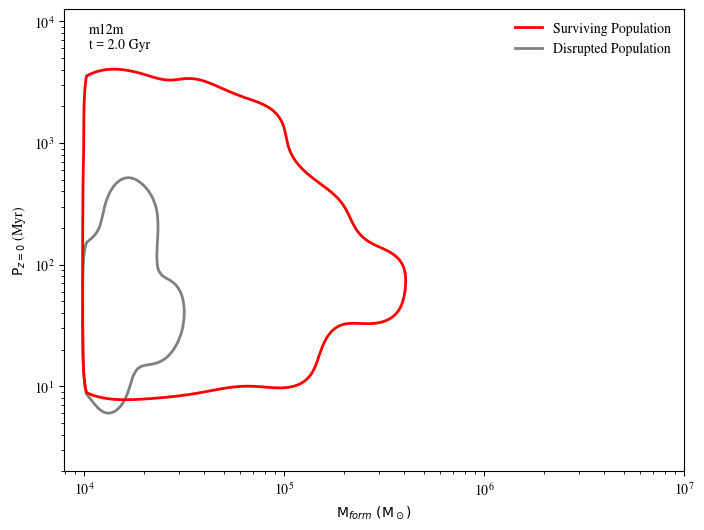

In [9]:
sim = "m12m"
in_msk = True
cont_level = 0.95

tcuts = np.arange(2, 14, 0.5)

gif_path = "../data/results/" + sim + "_tcut.gif"
gif_wrapping(
    plot_func=plot_cont_bounding,
    param_name="tcut",
    param_values=tcuts,
    gif_path=gif_path,
    fixed_kwargs=dict(sim=sim, in_msk=in_msk, cont_level=cont_level),
    interval=250,
)

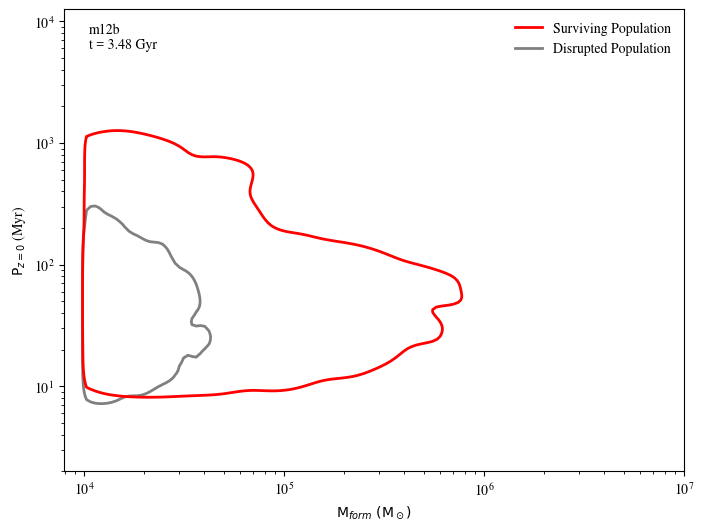

In [14]:
sim = "m12b"
in_msk = True
cont_level = 0.95
tcut = 3.48

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 6))
plot_cont_bounding(ax, sim, tcut, in_msk=True, cont_level=0.95)

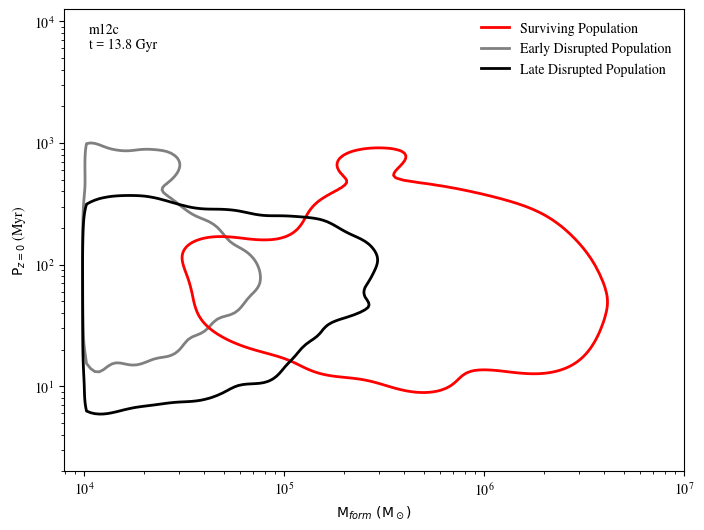

In [ ]:
sim = "m12c"
in_msk = True
cont_level = 0.75
tcut = time
tbound = 4.5

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 6))
plot_cont_bounding_mid(ax, sim, tcut, tbound, in_msk=True, cont_level=0.95)

Text(0, 0.5, '$\\mathrm{P}_{z=0}$ (Myr)')

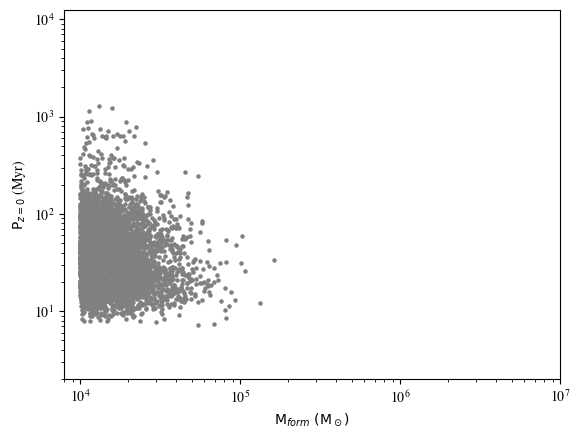

In [ ]:
sim = "m12b"
in_msk = True
it_id = "it001"
tcut = 4
acc = sim_dict[sim][it_id]["acc"] == in_msk
mfor = sim_dict[sim][it_id]["m_tfo"]
pz0 = sim_dict[sim][it_id]["t_tz0"]
sz0 = sim_dict[sim][it_id]["s_tz0"]
tdis = sim_dict[sim][it_id]["tdis"].copy()
tfor = sim_dict[sim][it_id]["tfor"]
tdis[tdis == -1] = np.inf

tmsk = tdis <= tcut
tformsk = tfor <= tcut

x0 = mfor[acc & tmsk & tformsk]
y0 = pz0[acc & tmsk & tformsk]
c0 = tcut - tfor[acc & tmsk & tformsk]

x1 = mfor[acc & ~tmsk & tformsk]
y1 = pz0[acc & ~tmsk & tformsk]
c1 = tcut - tfor[acc & ~tmsk & tformsk]

# plt.scatter(x0, y0, c=c0, s=5)
# plt.scatter(x1, y1, c=c1, s=5)
# plt.colorbar()
plt.scatter(x0, y0, c="grey", s=5)
# plt.scatter(x1, y1, c="r", s=10, alpha=0.1)

plt.xscale("log")
plt.yscale("log")

plt.xlim(10**3.9, 10**7)
plt.ylim(10**0.3, 10**4.1)

plt.xlabel(r"$\mathrm{M}_{form}\ (\mathrm{M}_\odot)$")
plt.ylabel(r"$\mathrm{P}_{z=0}$ (Myr)")

In [ ]:
def kde_threshold(Z, fraction):
    """Return KDE level that encloses fraction of total probability."""
    sorted_Z = np.sort(Z.ravel())[::-1]  # descending
    cumsum = np.cumsum(sorted_Z)
    cumsum /= cumsum[-1]  # normalize
    # Find the smallest Z value where cumulative sum >= fraction
    level = sorted_Z[np.searchsorted(cumsum, fraction)]
    return level


def rhs_envelope(y, m, y_b, x_b):
    """
    Right-hand-side envelope:
    flat for y < y_b,
    sloped to the right for y > y_b
    """
    return np.where(y > y_b, m * (y - y_b) + x_b, x_b)


2.0
2.5
3.0
3.5
4.0


/var/folders/nb/byfjq48d6jz8b3g74s3zr7rh0000gp/T/ipykernel_60951/1018028461.py:32: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  contour_path = cont.collections[0].get_paths()[0]


4.5
5.0
5.5
6.0
6.5
7.0
7.5
8.0
8.5
9.0
9.5
10.0
10.5
11.0
11.5
12.0
12.5
13.0
13.5


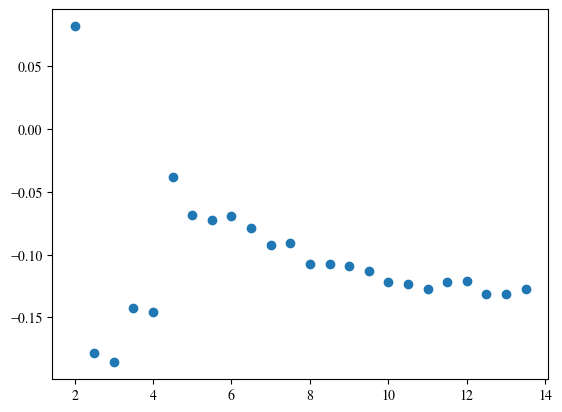

In [ ]:
######################################
def trial(sim_dict, sim, it_id, in_msk, tcut, fraction):
    acc = sim_dict[sim][it_id]["acc"] == in_msk
    mfor = sim_dict[sim][it_id]["m_tfo"]
    pz0 = sim_dict[sim][it_id]["t_tz0"]
    sz0 = sim_dict[sim][it_id]["s_tz0"]
    tdis = sim_dict[sim][it_id]["tdis"].copy()
    tfor = sim_dict[sim][it_id]["tfor"]
    tdis[tdis == -1] = np.inf

    tmsk = tdis <= tcut
    tformsk = tfor <= tcut

    x = mfor[acc & tmsk & tformsk]
    y = pz0[acc & tmsk & tformsk]

    xlog = np.log10(x)
    ylog = np.log10(y)

    xy = np.vstack([xlog, ylog])
    kde = gaussian_kde(xy)
    xmin, xmax = xlog.min(), xlog.max()
    ymin, ymax = ylog.min(), ylog.max()

    X, Y = np.meshgrid(np.linspace(xmin, xmax, 200), np.linspace(ymin, ymax, 200))
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

    level = kde_threshold(Z, fraction)
    cont = plt.contour(X, Y, Z, levels=[level], colors="orange")
    plt.close()

    contour_path = cont.collections[0].get_paths()[0]
    vertices = contour_path.vertices
    x_contour, y_contour = vertices[:, 0], vertices[:, 1]

    # --- Keep only the RIGHT-HAND SIDE of the contour ---
    # Bin in y and take the maximum x in each bin
    bins = np.linspace(y_contour.min(), y_contour.max(), 100)
    y_bin_centers = 0.5 * (bins[:-1] + bins[1:])

    x_rhs = []
    y_rhs = []

    for i in range(len(bins) - 1):
        mask = (y_contour >= bins[i]) & (y_contour < bins[i + 1])
        if np.any(mask):
            y_rhs.append(y_bin_centers[i])
            x_rhs.append(np.max(x_contour[mask]))

    y_rhs = np.array(y_rhs)
    x_rhs = np.array(x_rhs)

    # --- fit RHS envelope ---
    # p0 = [-0.5, np.median(y_rhs), np.median(x_rhs)]  # slope, y_b, x_b
    # params, cov = curve_fit(rhs_envelope, y_rhs, x_rhs, p0=p0)

    m, b = np.polyfit(y_rhs, x_rhs, 1)

    # --- evaluate fit ---
    # yfitlog = np.linspace(ymin, ymax, 300)
    # # xfitlog = rhs_envelope(yfitlog, *params)
    # xfitlog = m * yfitlog + b

    # yfit = 10**yfitlog
    # xfit = 10**xfitlog

    # plt.plot(xfit, yfit)
    # plt.scatter(x, y, c="grey", s=5)

    # plt.xscale("log")
    # plt.yscale("log")

    return m


sim = "m12m"
in_msk = True
it_id = "it001"
fraction = 0.98

tcuts = np.arange(2, 14, 0.5)
ms = []
for tcut in tcuts:
    print(tcut)
    ms.append(trial(sim_dict, sim, it_id, in_msk, tcut, fraction))

plt.scatter(tcuts, ms)

# The Missing Population

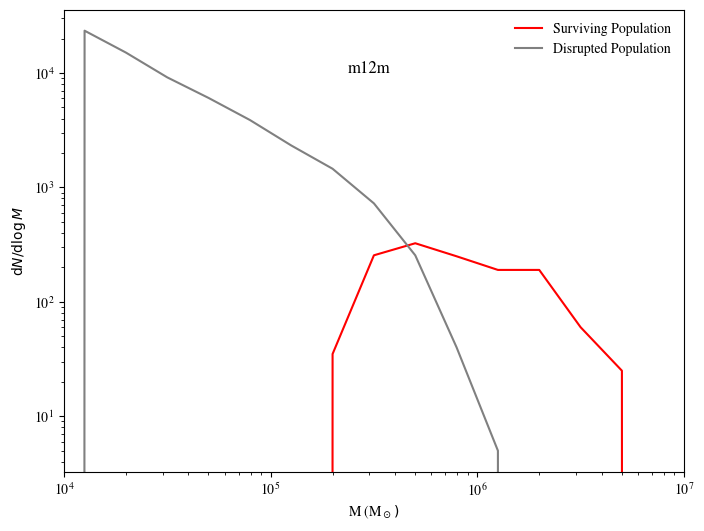

In [ ]:
sim = "m12m"
in_msk = True
tbound = None
it_id = "it001"

# bins = np.linspace(3, 7.2, 43)
bins = np.linspace(3, 7.2, 22)

acc = sim_dict[sim][it_id]["acc"] == in_msk
mfor = sim_dict[sim][it_id]["m_tfo"]
pz0 = sim_dict[sim][it_id]["t_tz0"]
stz0 = sim_dict[sim][it_id]["s_tz0"]
tdis = sim_dict[sim][it_id]["tdis"].copy()
tdis[tdis == -1] = np.inf

if tbound is None:
    x0 = mfor[~stz0 & acc]
    y0 = pz0[~stz0 & acc]
    x1 = mfor[stz0 & acc]
    y1 = pz0[stz0 & acc]

    label0 = "Disrupted Population"
else:
    tdis_msk = tdis <= tbound
    x0 = mfor[~stz0 & acc & tdis_msk]
    y0 = pz0[~stz0 & acc & tdis_msk]
    x1 = mfor[stz0 & acc]
    y1 = pz0[stz0 & acc]
    x2 = mfor[~stz0 & acc & ~tdis_msk]
    y2 = pz0[~stz0 & acc & ~tdis_msk]

    label0 = "Early Disrupted Population"

if in_msk:
    col = "r"
else:
    col = "b"

plt.figure(figsize=(8, 6))

logM1 = np.log10(x1)
N1, edges1 = np.histogram(logM1, bins=bins)
dlogM1 = np.diff(edges1)
dN1dlogM1 = N1 / dlogM1
logM1_centers = 0.5 * (edges1[1:] + edges1[:-1])
M1_centers = 10**logM1_centers
plt.plot(M1_centers, dN1dlogM1, c=col, label="Surviving Population")

logM0 = np.log10(x0)
N0, edges0 = np.histogram(logM0, bins=bins)
dlogM0 = np.diff(edges0)
dN0dlogM0 = N0 / dlogM0
logM0_centers = 0.5 * (edges0[1:] + edges0[:-1])
M0_centers = 10**logM0_centers
plt.plot(M0_centers, dN0dlogM0, c="grey", label=label0)

if tbound is not None:
    logM2 = np.log10(x2)
    N2, edges2 = np.histogram(logM2, bins=bins)
    dlogM2 = np.diff(edges2)
    dN2dlogM2 = N2 / dlogM2
    logM2_centers = 0.5 * (edges2[1:] + edges2[:-1])
    M2_centers = 10**logM2_centers
    plt.plot(M2_centers, dN2dlogM2, c="k", label="Late Disrupted Population")


plt.xlabel(r"M (M$_\odot)$")
plt.ylabel(r"$\mathrm{d}N / \mathrm{d}\log M$")

plt.xscale("log")
plt.yscale("log")

plt.text(3 * 10**5, 10**4, sim, fontsize=12, ha="center")
plt.xlim(10**4, 10**7)

plt.legend(frameon=False)

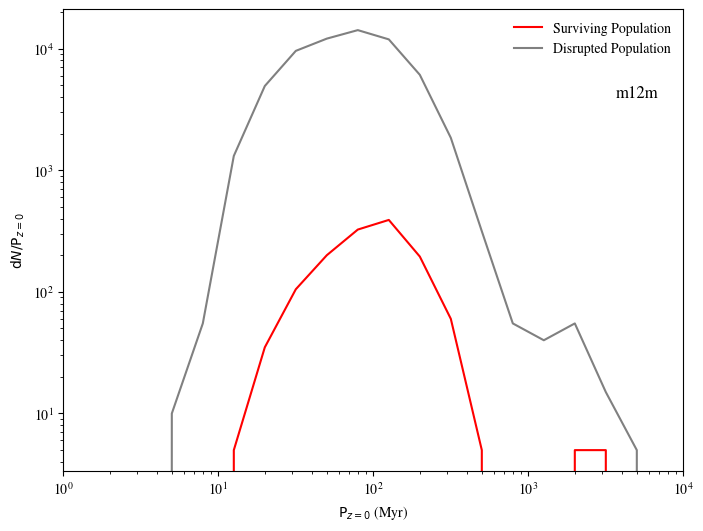

In [ ]:
sim = "m12m"
in_msk = True
tbound = None
it_id = "it001"

# bins = np.linspace(0.2, 4, 39)
bins = np.linspace(0.2, 4, 20)

acc = sim_dict[sim][it_id]["acc"] == in_msk
mfor = sim_dict[sim][it_id]["m_tfo"]
pz0 = sim_dict[sim][it_id]["t_tz0"]
stz0 = sim_dict[sim][it_id]["s_tz0"]
tdis = sim_dict[sim][it_id]["tdis"].copy()
tdis[tdis == -1] = np.inf

if tbound is None:
    x0 = mfor[~stz0 & acc]
    y0 = pz0[~stz0 & acc]
    x1 = mfor[stz0 & acc]
    y1 = pz0[stz0 & acc]

    label0 = "Disrupted Population"
else:
    tdis_msk = tdis <= tbound
    x0 = mfor[~stz0 & acc & tdis_msk]
    y0 = pz0[~stz0 & acc & tdis_msk]
    x1 = mfor[stz0 & acc]
    y1 = pz0[stz0 & acc]
    x2 = mfor[~stz0 & acc & ~tdis_msk]
    y2 = pz0[~stz0 & acc & ~tdis_msk]

    label0 = "Early Disrupted Population"

if in_msk:
    col = "r"
else:
    col = "b"

plt.figure(figsize=(8, 6))

logp1 = np.log10(y1)
N1, edges1 = np.histogram(logp1, bins=bins)
dlogp1 = np.diff(edges1)
dN1dlogp1 = N1 / dlogp1
logp1_centers = 0.5 * (edges1[1:] + edges1[:-1])
p1_centers = 10**logp1_centers
plt.plot(p1_centers, dN1dlogp1, c=col, label="Surviving Population")

logp0 = np.log10(y0)
N0, edges0 = np.histogram(logp0, bins=bins)
dlogp0 = np.diff(edges0)
dN0dlogp0 = N0 / dlogp0
logp0_centers = 0.5 * (edges0[1:] + edges0[:-1])
p0_centers = 10**logp0_centers
plt.plot(p0_centers, dN0dlogp0, c="grey", label=label0)

if tbound is not None:
    logp2 = np.log10(y2)
    N2, edges2 = np.histogram(logp2, bins=bins)
    dlogp2 = np.diff(edges2)
    dN2dlogp2 = N2 / dlogp2
    logp2_centers = 0.5 * (edges2[1:] + edges2[:-1])
    p2_centers = 10**logp2_centers
    plt.plot(p2_centers, dN2dlogp2, c="k", label="Late Disrupted Population")


plt.xlabel(r"$\mathrm{P}_{z=0}$ (Myr)")
plt.ylabel(r"$\mathrm{d}N / \mathrm{P}_{z=0}$")

plt.xscale("log")
plt.yscale("log")

plt.text(5 * 10**3, 4 * 10**3, sim, fontsize=12, ha="center")
plt.xlim(0.1 * 10**1, 10**4)

plt.legend(frameon=False)

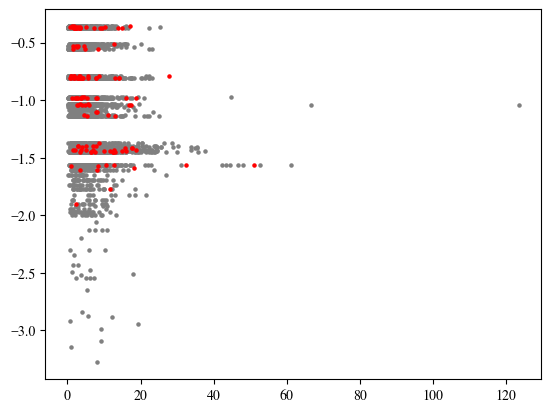

In [ ]:
sim = "m12i"
in_msk = True
tbound = None
it_id = "it001"

# bins = np.linspace(0.2, 4, 20)

acc = sim_dict[sim][it_id]["acc"] == in_msk
feh = sim_dict[sim][it_id]["feh"]
age = sim_dict[sim][it_id]["age"]
rz0 = sim_dict[sim][it_id]["rz0"]
stz0 = sim_dict[sim][it_id]["s_tz0"]
tdis = sim_dict[sim][it_id]["tdis"].copy()
tdis[tdis == -1] = np.inf

x0 = rz0[~stz0 & acc]
y0 = feh[~stz0 & acc]
x1 = rz0[stz0 & acc]
y1 = feh[stz0 & acc]

plt.scatter(x0, y0, c="grey", s=5)
plt.scatter(x1, y1, c="r", s=5)

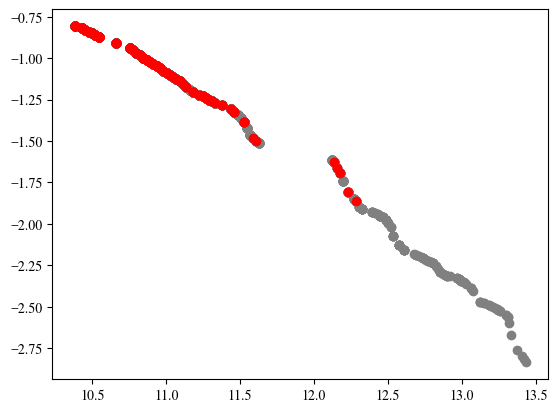

In [ ]:
x0 = age[~stz0 & acc]
y0 = feh[~stz0 & acc]

x1 = age[stz0 & acc]
y1 = feh[stz0 & acc]

plt.scatter(x0, y0, c="grey")
plt.scatter(x1, y1, c="r")

# Formation does not dictate survival?

# GRRRRR

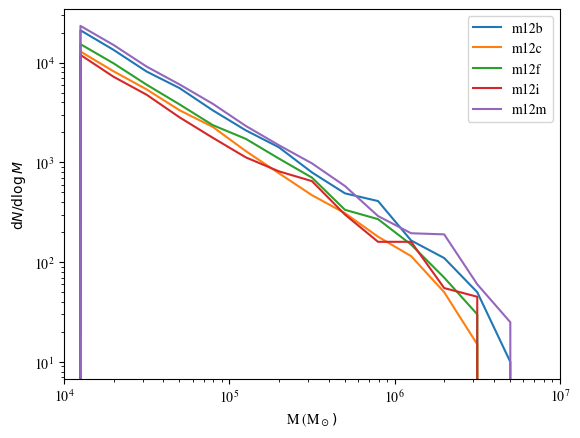

In [ ]:
sim = "m12b"
in_msk = True
it_id = "it001"

# bins = np.linspace(3, 7.2, 43)
bins = np.linspace(3, 7.2, 22)

for sim in sim_lst:
    acc = sim_dict[sim][it_id]["acc"] == in_msk
    mfor = sim_dict[sim][it_id]["m_tfo"]
    pz0 = sim_dict[sim][it_id]["t_tz0"]
    stz0 = sim_dict[sim][it_id]["s_tz0"]
    tdis = sim_dict[sim][it_id]["tdis"].copy()
    tdis[tdis == -1] = np.inf

    x0 = mfor[acc]
    y0 = pz0[acc]

    logM0 = np.log10(x0)
    N0, edges0 = np.histogram(logM0, bins=bins)
    dlogM0 = np.diff(edges0)
    dN0dlogM0 = N0 / dlogM0
    logM0_centers = 0.5 * (edges0[1:] + edges0[:-1])
    M0_centers = 10**logM0_centers
    plt.plot(M0_centers, dN0dlogM0, label=sim)


plt.xlabel(r"M (M$_\odot)$")
plt.ylabel(r"$\mathrm{d}N / \mathrm{d}\log M$")

plt.xscale("log")
plt.yscale("log")

plt.xlim(10**4, 10**7)

plt.legend()